# Retail Sales Forecasting Project
## Unit 7 – Final Modeling & Benchmarking
### Ismael Maizoumbou


## Problem Statement

The goal of this project is to predict weekly retail sales and identify key factors that influence sales performance. This supports business decisions such as inventory planning, staffing, promotions, and operational efficiency.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## Load Data

The project uses three datasets: the training sales data, the features data, and the stores data. These files are merged to create one analytical dataset for model development.


In [2]:
train = pd.read_csv("/Users/maizoumbou1/Desktop/IN599/train.csv")
features = pd.read_csv("/Users/maizoumbou1/Desktop/IN599/features.csv")
stores = pd.read_csv("/Users/maizoumbou1/Desktop/IN599/data/stores.csv")

train["Date"] = pd.to_datetime(train["Date"])
features["Date"] = pd.to_datetime(features["Date"])

df = train.merge(features, on=["Store", "Date", "IsHoliday"])
df = df.merge(stores, on="Store")

df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

df.fillna(0, inplace=True)
df.head()


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Month,Year
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315,2,2010
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,A,151315,2,2010
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,A,151315,2,2010
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,A,151315,2,2010
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,A,151315,3,2010


## Prepare Data

The store type field is categorical, so it is converted into numeric dummy variables. The predictor variables include store information, department, holiday indicator, economic variables, store size, and time-based features.


In [3]:
df = pd.get_dummies(df, columns=["Type"], drop_first=True)

features_list = [
    "Store", "Dept", "IsHoliday", "Temperature", "Fuel_Price",
    "CPI", "Unemployment", "Size", "Month", "Year"
]

X = df[features_list]
y = df["Weekly_Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (337256, 10)
Testing set shape: (84314, 10)


## Build Models

Three models are developed and compared: Linear Regression, Decision Tree Regression, and Random Forest Regression. Linear Regression is used as a baseline model, Decision Tree provides a rule-based comparison, and Random Forest is tuned with GridSearchCV to identify stronger model parameters.


In [4]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

# Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)

# Random Forest with GridSearchCV
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [10, 20]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

rf = grid.best_estimator_
pred_rf = rf.predict(X_test)

print("Best Parameters:", grid.best_params_)


Best Parameters: {'max_depth': 20, 'n_estimators': 100}


## Model Evaluation

The models are evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared. MAE and RMSE measure prediction error, while R-squared explains how much variation in weekly sales is captured by the model.


In [5]:
def eval_model(y_true, pred):
    mae = mean_absolute_error(y_true, pred)
    rmse = mean_squared_error(y_true, pred) ** 0.5
    r2 = r2_score(y_true, pred)
    return mae, rmse, r2

lr_mae, lr_rmse, lr_r2 = eval_model(y_test, pred_lr)
dt_mae, dt_rmse, dt_r2 = eval_model(y_test, pred_dt)
rf_mae, rf_rmse, rf_r2 = eval_model(y_test, pred_rf)

results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "MAE": [lr_mae, dt_mae, rf_mae],
    "RMSE": [lr_rmse, dt_rmse, rf_rmse],
    "R2": [lr_r2, dt_r2, rf_r2]
})

results


,Model,MAE,RMSE,R2
0,Linear Regression,14556.453620,21814.908863,0.087408
1,Decision Tree,2070.571021,5413.092657,0.943810
2,Random Forest,1672.632282,4356.510828,0.963605


## Visualizations

The following visuals show the Random Forest model performance and interpretation. The actual-versus-predicted plot compares model predictions to real sales values. The feature importance chart identifies the strongest predictors. The residual plot shows the spread of prediction errors.


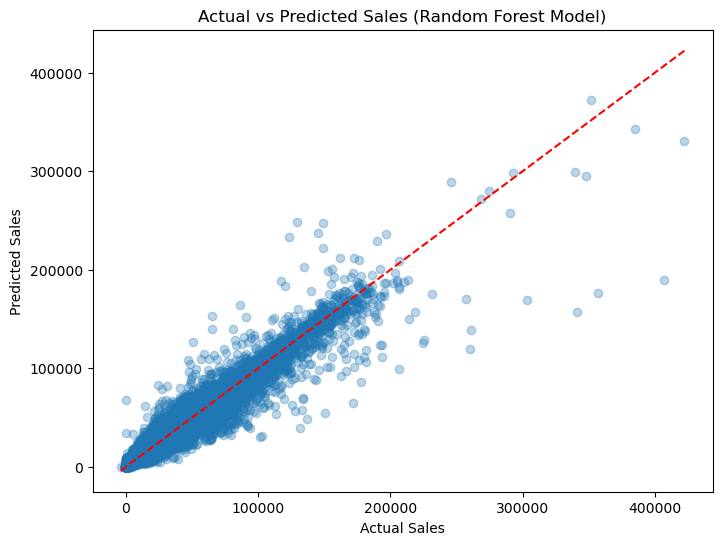

In [6]:
# Actual vs Predicted
plt.figure(figsize=(8, 6))

plt.scatter(y_test, pred_rf, alpha=0.3)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales (Random Forest Model)")
plt.show()


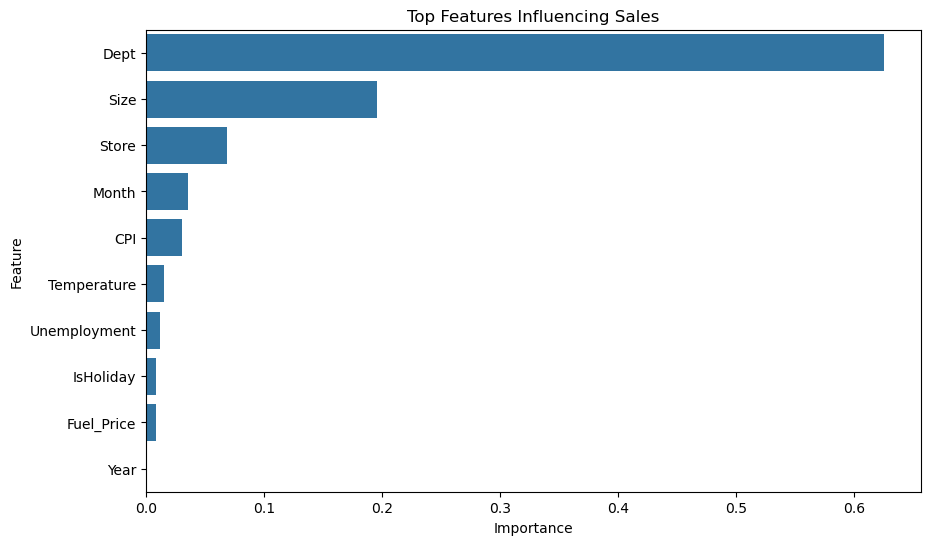

,Feature,Importance
1,Dept,0.625605
7,Size,0.195381
0,Store,0.068451
8,Month,0.035727
5,CPI,0.030523
3,Temperature,0.014909
6,Unemployment,0.011862
2,IsHoliday,0.008623
4,Fuel_Price,0.008328
9,Year,0.000590


In [7]:
# Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance.head(10), x="Importance", y="Feature")
plt.title("Top Features Influencing Sales")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

importance.head(10)


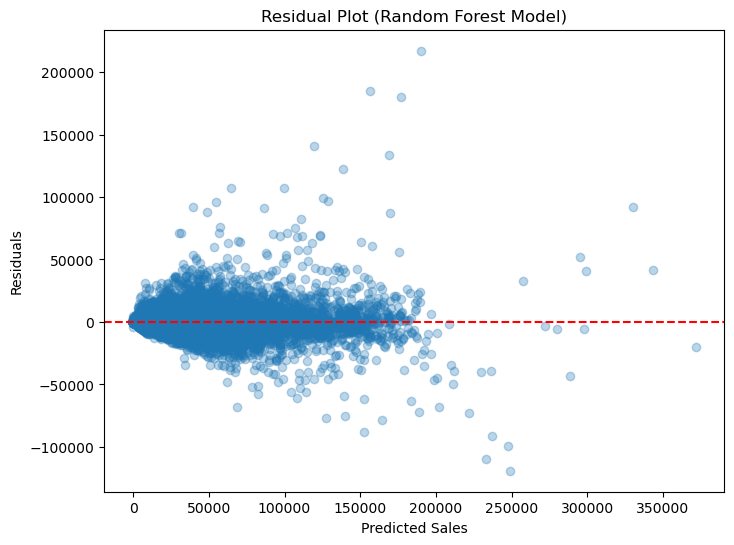

In [8]:
# Residual Plot
residuals = y_test - pred_rf

plt.figure(figsize=(8, 6))
plt.scatter(pred_rf, residuals, alpha=0.3)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot (Random Forest Model)")
plt.show()


## Model Evaluation and Insights

The Random Forest model outperformed both Linear Regression and Decision Tree models based on RMSE and R-squared values. This indicates that retail sales patterns are complex and involve non-linear relationships.

According to Pedregosa et al. (2011), machine learning models such as Random Forest are effective for capturing complex relationships in data.

The Linear Regression model showed lower performance, suggesting that the relationship between variables is not purely linear. The Decision Tree model showed moderate performance but may be more sensitive to overfitting because it creates specific decision rules from the training data.

The actual-versus-predicted plot helps show how close the Random Forest predictions are to the actual weekly sales values. Points closer to the red dashed line represent more accurate predictions. The residual plot provides another view of prediction error, while the feature importance chart helps explain which variables contributed most to the Random Forest model.


## Business Insights

- Store size strongly impacts sales, which suggests that larger stores may require more inventory and staffing support.
- Seasonal trends affect sales performance, meaning month-based planning can support better forecasting.
- External factors such as CPI and unemployment influence demand and should be considered in forecasting.
- These insights can also support promotional planning by identifying peak sales periods and optimizing marketing strategies.

These findings can also support pricing strategies by identifying demand patterns across departments.

Overall, the analysis provides actionable insight into the sales forecasting problem by identifying which model performs best and which variables appear most useful for prediction.


## Conclusion

This project successfully compared multiple machine learning models for predicting retail sales. The Random Forest model is recommended due to its higher accuracy and ability to capture complex, non-linear relationships between variables.

The results demonstrate that factors such as store size, department, and seasonal trends significantly influence sales performance. These insights can help businesses improve forecasting accuracy, optimize inventory levels, and enhance staffing decisions.

Overall, this analysis provides actionable insights that support more effective and data-driven retail operations.


## References

Kaggle. (n.d.). *Walmart store sales forecasting dataset*. Retrieved from https://www.kaggle.com/c/walmart-recruiting-store-sales-forecasting/data

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., VanderPlas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.
